In [1]:
from pathlib import Path
import os

# If notebook runs from test_notebooks/, move to repo root first.
if Path.cwd().name == 'test_notebooks':
    os.chdir('..')

print('Current working directory:', Path.cwd())


Current working directory: /home/bhchen/LearnKalmanGain


IEnKF: missing target N [3000], keep corresponding rows blank.


Saved 47 subfigure images to: save/figures/doubling1d_subfigures/step_100
Saved prior/posterior combined grid image to: save/doubling1d_results/doubling1d_results_grid_step100_prior_posterior_with_benchmarks_and_legend.png
Saved prior/posterior combined grid PDF to: save/doubling1d_results/doubling1d_results_grid_step100_prior_posterior_with_benchmarks_and_legend.pdf


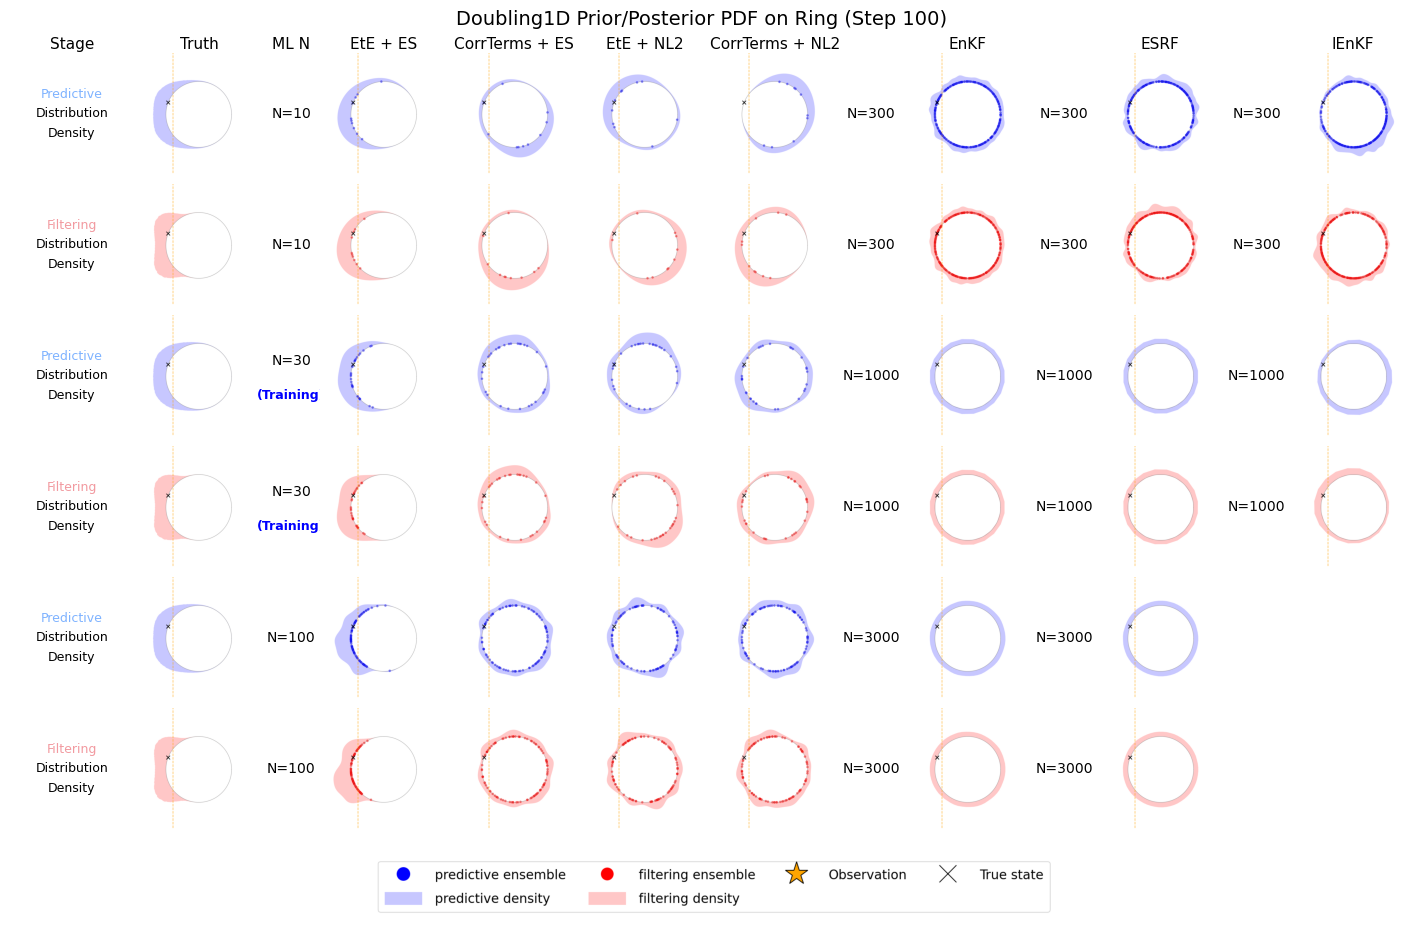

Saved 47 subfigure images to: save/figures/doubling1d_subfigures/step_150
Saved prior/posterior combined grid image to: save/doubling1d_results/doubling1d_results_grid_step150_prior_posterior_with_benchmarks_and_legend.png
Saved prior/posterior combined grid PDF to: save/doubling1d_results/doubling1d_results_grid_step150_prior_posterior_with_benchmarks_and_legend.pdf


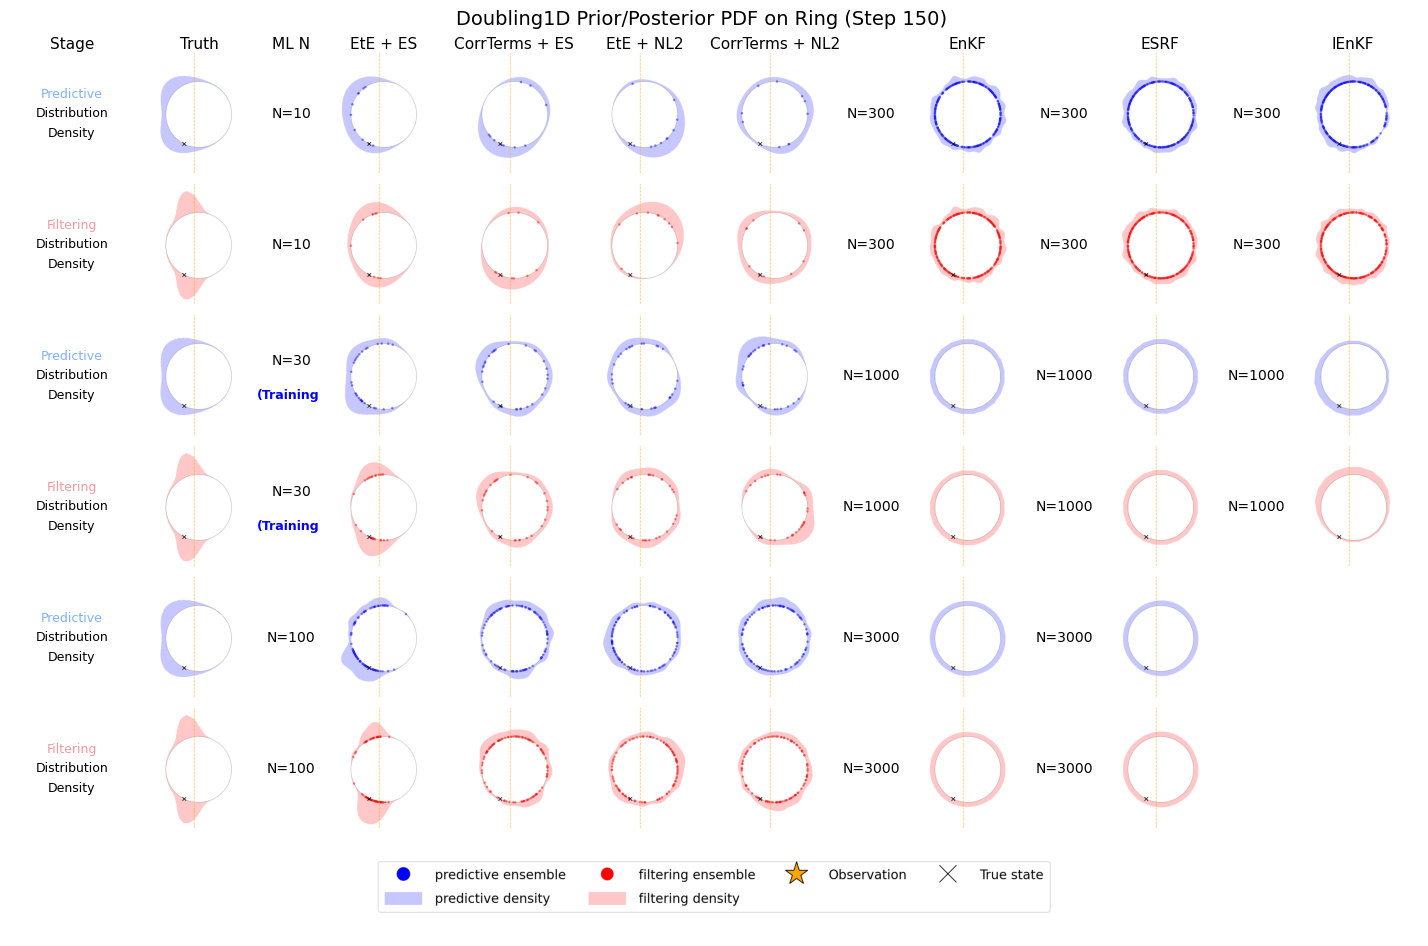

Saved 47 subfigure images to: save/figures/doubling1d_subfigures/step_200
Saved prior/posterior combined grid image to: save/doubling1d_results/doubling1d_results_grid_step200_prior_posterior_with_benchmarks_and_legend.png
Saved prior/posterior combined grid PDF to: save/doubling1d_results/doubling1d_results_grid_step200_prior_posterior_with_benchmarks_and_legend.pdf


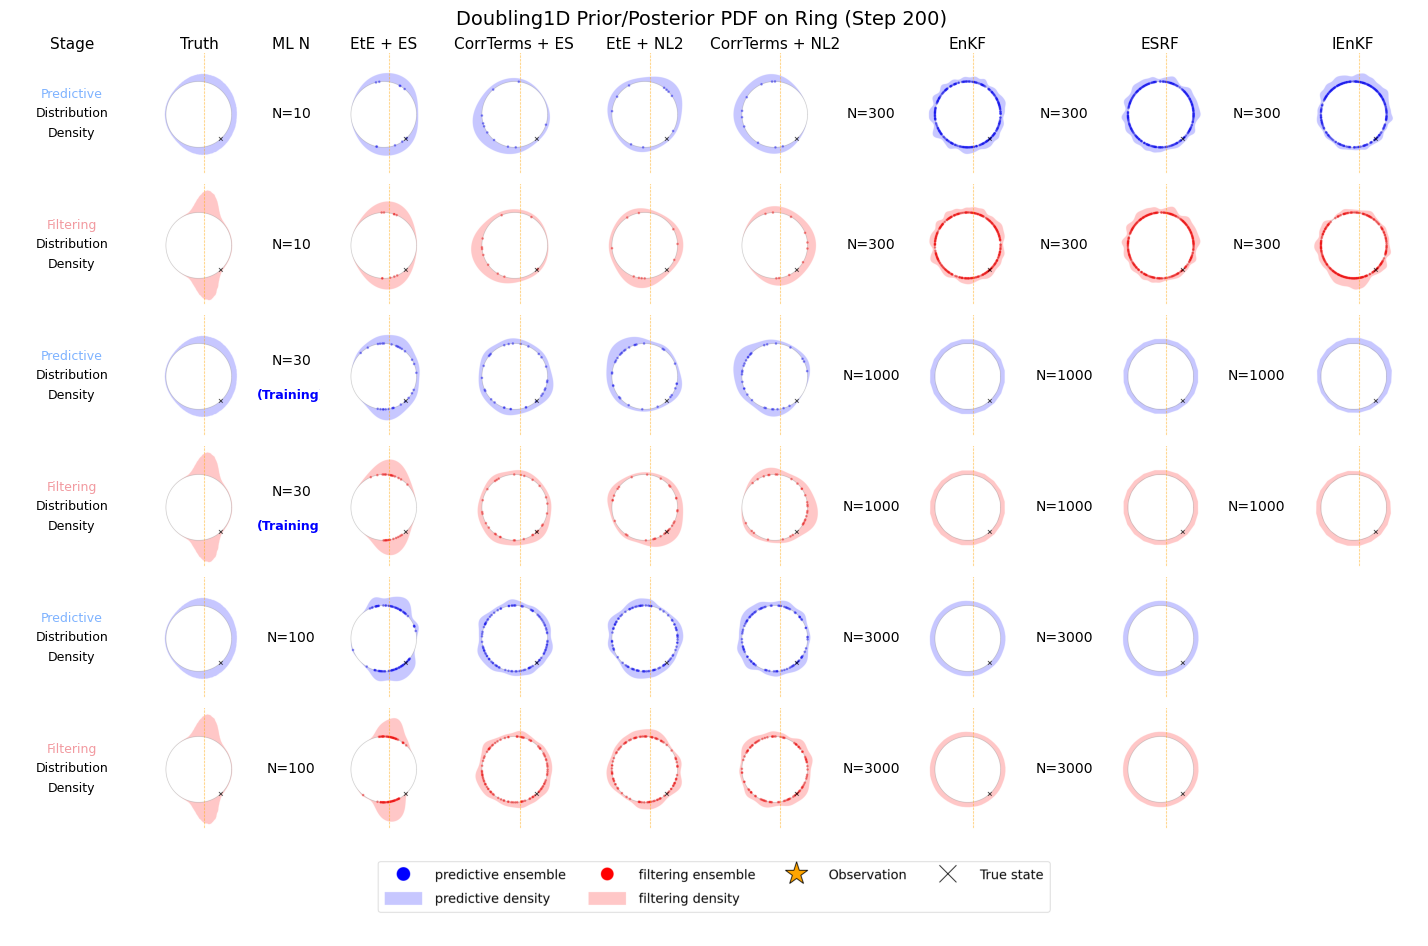

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt

base_dir = Path('save/doubling1d_results')
enkf_dir = Path('save/benchmark_doubling1d_0.2_EnKF')
legend_path = enkf_dir / 'prior_post_density_combined_legend.png'
truth_dir = Path('save/doubling1d_pf_vis')
subfigure_root = Path('save/figures/doubling1d_subfigures')

methods = [
    ('EtE + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_EtE-LResNone_cos2pi'),
    ('CorrTerms + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_CorrTermsNone_cos2pi'),
    ('EtE + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_EtE-LResNone_cos2pi'),
    ('CorrTerms + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_CorrTermsNone_cos2pi'),
]
benchmark_methods = [
    ('EnKF', Path('save/benchmark_doubling1d_0.2_EnKF')),
    ('ESRF', Path('save/benchmark_doubling1d_0.2_ESRF')),
    ('IEnKF', Path('save/benchmark_doubling1d_0.2_iEnKS-PertObs')),
]

steps = [100, 150, 200]
ml_ensemble_sizes = [10, 30, 100]
benchmark_target_ensemble_sizes = [300, 1000, 3000]
seed = 0
row_stages = [
    ('Predictive\nDistribution\nDensity', 'prior', 'PRIOR'),
    ('Filtering\nDistribution\nDensity', 'post', 'POST'),
]

legend_crop = {
    'left': 0.0,
    'right': 0.0,
    'top': 0.2,
    'bottom': 0.2,
}
image_crop = {
    'left': 0.1,
    'right': 0.05,
    'top': 0.05,
    'bottom': 0.1,
}
legend_height_ratio = 0.8

if len(ml_ensemble_sizes) != len(benchmark_target_ensemble_sizes):
    raise ValueError('ML and benchmark target ensemble-size lists must have the same length.')

required_paths = [base_dir, truth_dir] + [benchmark_dir for _, benchmark_dir in benchmark_methods]
for required_path in required_paths:
    if not required_path.exists():
        raise FileNotFoundError(f'Missing required directory: {required_path}')

if not legend_path.exists():
    raise FileNotFoundError(f'Missing legend image: {legend_path}')


def get_available_ns(benchmark_dir):
    ns = []
    for path in benchmark_dir.glob('output_records_*.pt'):
        try:
            ns.append(int(path.stem.replace('output_records_', '')))
        except ValueError:
            continue
    if not ns:
        raise FileNotFoundError(f'No output_records_*.pt files found in {benchmark_dir}')
    return sorted(set(ns))


def resolve_benchmark_ns(available_ns, target_ns, allow_fallback):
    resolved = []
    for target in target_ns:
        if target in available_ns:
            resolved.append(target)
            continue
        if allow_fallback:
            smaller_or_equal = [n for n in available_ns if n <= target]
            if smaller_or_equal:
                resolved.append(max(smaller_or_equal))
            else:
                resolved.append(min(available_ns))
        else:
            resolved.append(None)
    return resolved


benchmark_ns_map = {}
for benchmark_label, benchmark_dir in benchmark_methods:
    available_ns = get_available_ns(benchmark_dir)
    allow_fallback = benchmark_label != 'IEnKF'
    resolved_ns = resolve_benchmark_ns(available_ns, benchmark_target_ensemble_sizes, allow_fallback)
    benchmark_ns_map[benchmark_label] = resolved_ns
    if allow_fallback and resolved_ns != benchmark_target_ensemble_sizes:
        print(
            f'{benchmark_label}: fallback benchmark N list {resolved_ns} '
            f'(target was {benchmark_target_ensemble_sizes}, available {available_ns})'
        )
    if not allow_fallback:
        missing_targets = [target for target, resolved in zip(benchmark_target_ensemble_sizes, resolved_ns) if resolved is None]
        if missing_targets:
            print(f'{benchmark_label}: missing target N {missing_targets}, keep corresponding rows blank.')


def crop_image(image, crop):
    h, w = image.shape[:2]
    left = int(w * crop.get('left', 0.0))
    right = int(w * crop.get('right', 0.0))
    top = int(h * crop.get('top', 0.0))
    bottom = int(h * crop.get('bottom', 0.0))

    if left + right >= w:
        raise ValueError('Crop left+right ratio exceeds 1.0.')
    if top + bottom >= h:
        raise ValueError('Crop top+bottom ratio exceeds 1.0.')

    x_end = w - right if right > 0 else w
    y_end = h - bottom if bottom > 0 else h
    return image[top:y_end, left:x_end]


def get_truth_path(step, truth_tag):
    timestep = step - 1
    return truth_dir / (
        f'sigma_y0.2_batch64_len200_pfN1000000_timestep{timestep}_42_g0_{truth_tag}_0_ring_pdf_on_ring_nohist.png'
    )


def get_ml_path(method_folder, ml_n, step, stage_key):
    prefix = f'test_{ml_n}_{seed}'
    if stage_key == 'prior':
        prefix += '_prior'
    return base_dir / method_folder / f'{prefix}_g0_slice_step{step}_0_ring_pdf_on_ring_nohist.png'


def get_benchmark_path(benchmark_dir, benchmark_n, step, stage_key):
    stage_token = 'classic_prior' if stage_key == 'prior' else 'classic'
    return benchmark_dir / f'test_{benchmark_n}_0_{stage_token}_g0_slice_step{step}_0_ring_pdf_on_ring_nohist.png'


def sanitize_token(value):
    token = ''.join(ch.lower() if ch.isalnum() else '_' for ch in str(value))
    while '__' in token:
        token = token.replace('__', '_')
    return token.strip('_')


def queue_subfigure(subfigure_entries, image, *parts):
    filename = '_'.join(sanitize_token(part) for part in parts if part is not None) + '.png'
    subfigure_entries.append((filename, image))


def save_grid_image(step, legend_img):
    truth_imgs = {}
    for stage_label, stage_key, truth_tag in row_stages:
        truth_path = get_truth_path(step, truth_tag)
        if not truth_path.exists():
            raise FileNotFoundError(f'Missing truth image for {stage_label.lower()} step {step}: {truth_path}')
        truth_imgs[stage_key] = crop_image(plt.imread(truth_path), image_crop)

    step_subfigure_dir = subfigure_root / f'step_{step}'
    subfigure_entries = []

    rows_per_n = len(row_stages)
    nrows = len(ml_ensemble_sizes) * rows_per_n

    col_stage = 0
    col_truth = 1
    col_ml_n = 2
    col_methods_start = 3
    col_benchmark_start = col_methods_start + len(methods)

    benchmark_width_ratios = []
    benchmark_titles = []
    for benchmark_label, _ in benchmark_methods:
        benchmark_width_ratios.extend([0.48, 1.0])
        benchmark_titles.extend(['', benchmark_label])

    ncols = col_benchmark_start + 2 * len(benchmark_methods)
    width_ratios = [0.95, 1.0, 0.42] + [1.0] * len(methods) + benchmark_width_ratios

    fig_height = 1.3 * nrows + 1.8
    fig = plt.figure(figsize=(14.4, fig_height))
    gs = fig.add_gridspec(
        nrows=nrows + 1,
        ncols=ncols,
        width_ratios=width_ratios,
        height_ratios=[1] * nrows + [legend_height_ratio],
    )
    axes = [[fig.add_subplot(gs[r, c]) for c in range(ncols)] for r in range(nrows)]

    column_titles = ['Stage', 'Truth', 'ML N'] + [m[0] for m in methods] + benchmark_titles
    for col, title in enumerate(column_titles):
        axes[0][col].set_title(title, fontsize=11, pad=3)

    missing = []
    for pair_idx, ml_n in enumerate(ml_ensemble_sizes):
        base_row = pair_idx * rows_per_n
        for stage_offset, (_, stage_key, _) in enumerate(row_stages):
            row = base_row + stage_offset

            ax_stage = axes[row][col_stage]
            ax_stage.axis('off')
            if stage_key == 'prior':
                ax_stage.text(0.5, 0.66, 'Predictive', ha='center', va='center', fontsize=9, color='#7fb3ff')
                ax_stage.text(0.5, 0.50, 'Distribution', ha='center', va='center', fontsize=9)
                ax_stage.text(0.5, 0.34, 'Density', ha='center', va='center', fontsize=9)
            else:
                ax_stage.text(0.5, 0.66, 'Filtering', ha='center', va='center', fontsize=9, color='#f29aa0')
                ax_stage.text(0.5, 0.50, 'Distribution', ha='center', va='center', fontsize=9)
                ax_stage.text(0.5, 0.34, 'Density', ha='center', va='center', fontsize=9)

            truth_img = truth_imgs[stage_key]
            axes[row][col_truth].imshow(truth_img)
            axes[row][col_truth].axis('off')
            queue_subfigure(subfigure_entries, truth_img, 'truth', f'n{ml_n}', stage_key)

            ax_ml_n = axes[row][col_ml_n]
            ax_ml_n.axis('off')
            if ml_n == 30:
                ax_ml_n.text(0.5, 0.62, f'N={ml_n}', ha='center', va='center', fontsize=10)
                ax_ml_n.text(0.5, 0.34, '(Training)', ha='center', va='center', fontsize=9, color='blue', weight='bold')
            else:
                ax_ml_n.text(0.5, 0.5, f'N={ml_n}', ha='center', va='center', fontsize=10)

            for i, (method_label, method_folder) in enumerate(methods):
                col = col_methods_start + i
                ax = axes[row][col]
                image_path = get_ml_path(method_folder, ml_n, step, stage_key)
                if not image_path.exists():
                    missing.append(f'{stage_key} ML n={ml_n}: {image_path}')
                    ax.axis('off')
                    ax.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=10)
                    continue
                image = crop_image(plt.imread(image_path), image_crop)
                ax.imshow(image)
                ax.axis('off')
                queue_subfigure(subfigure_entries, image, 'ml', method_label, f'n{ml_n}', stage_key)

            for benchmark_idx, (benchmark_label, benchmark_dir) in enumerate(benchmark_methods):
                benchmark_n = benchmark_ns_map[benchmark_label][pair_idx]
                col_benchmark_n = col_benchmark_start + 2 * benchmark_idx
                col_benchmark_img = col_benchmark_n + 1

                ax_benchmark_n = axes[row][col_benchmark_n]
                ax_benchmark = axes[row][col_benchmark_img]
                ax_benchmark_n.axis('off')
                ax_benchmark.axis('off')

                if benchmark_n is None:
                    continue

                ax_benchmark_n.text(0.5, 0.5, f'N={benchmark_n}', ha='center', va='center', fontsize=10)

                benchmark_path = get_benchmark_path(benchmark_dir, benchmark_n, step, stage_key)
                if not benchmark_path.exists():
                    missing.append(f'{stage_key} {benchmark_label} n={benchmark_n}: {benchmark_path}')
                    ax_benchmark.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=10)
                else:
                    image = crop_image(plt.imread(benchmark_path), image_crop)
                    ax_benchmark.imshow(image)
                    ax_benchmark.axis('off')
                    queue_subfigure(subfigure_entries, image, 'benchmark', benchmark_label, f'n{benchmark_n}', f'ml_n{ml_n}', stage_key)

    if missing:
        raise FileNotFoundError(
            f'Some expected images were not found for step {step}:\n' + '\n'.join(missing)
        )

    legend_ax = fig.add_subplot(gs[nrows, :])
    legend_ax.imshow(legend_img, aspect='equal')
    legend_ax.axis('off')
    queue_subfigure(subfigure_entries, legend_img, 'legend')

    step_subfigure_dir.mkdir(parents=True, exist_ok=True)
    for filename, image in subfigure_entries:
        plt.imsave(step_subfigure_dir / filename, image)

    fig.suptitle(f'Doubling1D Prior/Posterior PDF on Ring (Step {step})', fontsize=14, y=0.995)
    fig.subplots_adjust(left=0.02, right=0.998, top=0.95, bottom=0.03, wspace=0.0, hspace=0.08)

    output_path = base_dir / f'doubling1d_results_grid_step{step}_prior_posterior_with_benchmarks_and_legend.png'
    output_pdf_path = output_path.with_suffix('.pdf')
    fig.savefig(output_path, dpi=260, bbox_inches='tight', pad_inches=0.02)
    fig.savefig(output_pdf_path, bbox_inches='tight', pad_inches=0.02)
    print(f'Saved {len(subfigure_entries)} subfigure images to: {step_subfigure_dir}')
    print(f'Saved prior/posterior combined grid image to: {output_path}')
    print(f'Saved prior/posterior combined grid PDF to: {output_pdf_path}')
    plt.show()


legend_img = crop_image(plt.imread(legend_path), legend_crop)

for step in steps:
    save_grid_image(step, legend_img)





Saved filtering-only compact grid image to: save/doubling1d_results/doubling1d_results_grid_steps100_150_200_filtering_mlN30_benchmarkN1000_with_legend.png
Saved filtering-only compact grid PDF to: save/doubling1d_results/doubling1d_results_grid_steps100_150_200_filtering_mlN30_benchmarkN1000_with_legend.pdf


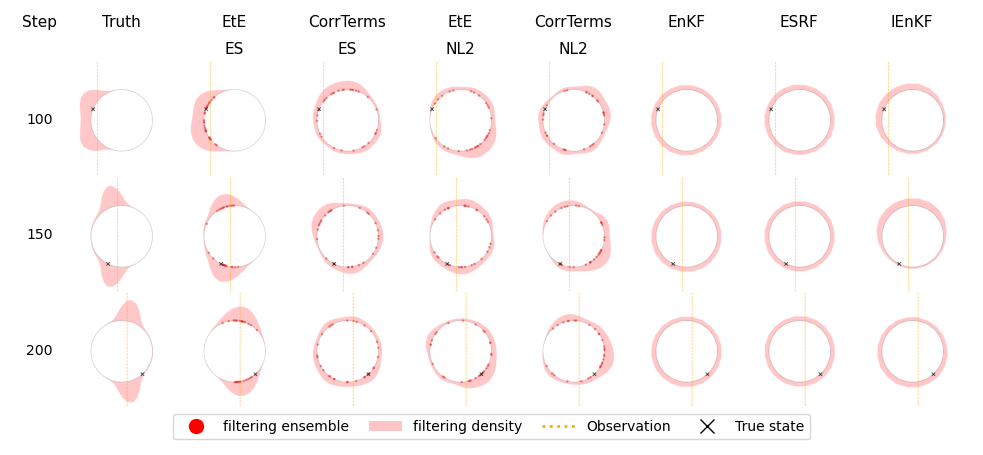

In [3]:
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

compact_base_dir = Path('save/doubling1d_results')
compact_truth_dir = Path('save/doubling1d_pf_vis')

compact_methods = [
    ('EtE + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_EtE-LResNone_cos2pi'),
    ('CorrTerms + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_CorrTermsNone_cos2pi'),
    ('EtE + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_EtE-LResNone_cos2pi'),
    ('CorrTerms + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_CorrTermsNone_cos2pi'),
]
compact_benchmark_methods = [
    ('EnKF', Path('save/benchmark_doubling1d_0.2_EnKF')),
    ('ESRF', Path('save/benchmark_doubling1d_0.2_ESRF')),
    ('IEnKF', Path('save/benchmark_doubling1d_0.2_iEnKS-PertObs')),
]

compact_steps = [100, 150, 200]
compact_ml_n = 30
compact_benchmark_n = 1000
compact_seed = 0
compact_image_crop = {
    'left': 0.1,
    'right': 0.05,
    'top': 0.05,
    'bottom': 0.1,
}
compact_legend_height_ratio = 0.32


def compact_crop_image(image, crop):
    h, w = image.shape[:2]
    left = int(w * crop.get('left', 0.0))
    right = int(w * crop.get('right', 0.0))
    top = int(h * crop.get('top', 0.0))
    bottom = int(h * crop.get('bottom', 0.0))

    if left + right >= w:
        raise ValueError('Crop left+right ratio exceeds 1.0.')
    if top + bottom >= h:
        raise ValueError('Crop top+bottom ratio exceeds 1.0.')

    x_end = w - right if right > 0 else w
    y_end = h - bottom if bottom > 0 else h
    return image[top:y_end, left:x_end]


def compact_get_truth_path(step):
    timestep = step - 1
    return compact_truth_dir / (
        f'sigma_y0.2_batch64_len200_pfN1000000_timestep{timestep}_42_g0_POST_0_ring_pdf_on_ring_nohist.png'
    )


def compact_get_ml_path(method_folder, step):
    return compact_base_dir / method_folder / (
        f'test_{compact_ml_n}_{compact_seed}_g0_slice_step{step}_0_ring_pdf_on_ring_nohist.png'
    )


def compact_get_benchmark_path(benchmark_dir, step):
    return benchmark_dir / (
        f'test_{compact_benchmark_n}_0_classic_g0_slice_step{step}_0_ring_pdf_on_ring_nohist.png'
    )


def save_compact_filtering_grid():
    required_dirs = [compact_base_dir, compact_truth_dir] + [benchmark_dir for _, benchmark_dir in compact_benchmark_methods]
    for required_dir in required_dirs:
        if not required_dir.exists():
            raise FileNotFoundError(f'Missing required directory: {required_dir}')
    header_rows = 2
    data_rows = len(compact_steps)
    nrows = header_rows + data_rows
    col_step = 0
    col_truth = 1
    col_methods_start = 2
    col_benchmark_start = col_methods_start + len(compact_methods)

    ncols = col_benchmark_start + len(compact_benchmark_methods)
    width_ratios = [0.40, 0.82] + [0.82] * len(compact_methods) + [0.82] * len(compact_benchmark_methods)
    fig_height = 1.22 * data_rows + 1.05
    fig = plt.figure(figsize=(9.8, fig_height))
    gs = fig.add_gridspec(
        nrows=nrows + 1,
        ncols=ncols,
        width_ratios=width_ratios,
        height_ratios=[0.22, 0.22] + [1] * data_rows + [compact_legend_height_ratio],
    )
    axes = [[fig.add_subplot(gs[r, c]) for c in range(ncols)] for r in range(nrows)]

    ml_method_headers = []
    ml_loss_headers = []
    for method_label, _ in compact_methods:
        method_name, loss_name = method_label.split(' + ', maxsplit=1)
        ml_method_headers.append(method_name)
        ml_loss_headers.append(loss_name)
    method_headers = ['Step', 'Truth'] + ml_method_headers + [label for label, _ in compact_benchmark_methods]
    loss_headers = ['', ''] + ml_loss_headers + [''] * len(compact_benchmark_methods)

    for header_row, header_values in enumerate((method_headers, loss_headers)):
        for col, title in enumerate(header_values):
            ax = axes[header_row][col]
            ax.axis('off')
            if title:
                ax.text(0.5, 0.5, title, ha='center', va='center', fontsize=11)

    missing = []
    for data_row, step in enumerate(compact_steps):
        row = header_rows + data_row
        ax_step = axes[row][col_step]
        ax_step.axis('off')
        ax_step.text(0.5, 0.5, str(step), ha='center', va='center', fontsize=10)

        truth_path = compact_get_truth_path(step)
        ax_truth = axes[row][col_truth]
        ax_truth.axis('off')
        if not truth_path.exists():
            missing.append(f'filtering truth step={step}: {truth_path}')
            ax_truth.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=10)
        else:
            truth_img = compact_crop_image(plt.imread(truth_path), compact_image_crop)
            ax_truth.imshow(truth_img)

        for method_idx, (method_label, method_folder) in enumerate(compact_methods):
            col = col_methods_start + method_idx
            ax = axes[row][col]
            ax.axis('off')
            image_path = compact_get_ml_path(method_folder, step)
            if not image_path.exists():
                missing.append(f'filtering ML {method_label} n={compact_ml_n} step={step}: {image_path}')
                ax.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=10)
            else:
                image = compact_crop_image(plt.imread(image_path), compact_image_crop)
                ax.imshow(image)

        for benchmark_idx, (benchmark_label, benchmark_dir) in enumerate(compact_benchmark_methods):
            col = col_benchmark_start + benchmark_idx
            ax = axes[row][col]
            ax.axis('off')
            benchmark_path = compact_get_benchmark_path(benchmark_dir, step)
            if not benchmark_path.exists():
                missing.append(f'filtering {benchmark_label} n={compact_benchmark_n} step={step}: {benchmark_path}')
                ax.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=10)
            else:
                image = compact_crop_image(plt.imread(benchmark_path), compact_image_crop)
                ax.imshow(image)

    if missing:
        raise FileNotFoundError('Some expected images were not found:\n' + '\n'.join(missing))

    legend_ax = fig.add_subplot(gs[nrows, :])
    legend_ax.axis('off')
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='None', color='red', markersize=10, label='filtering ensemble'),
        Patch(facecolor='#ffb6b6', edgecolor='none', alpha=0.8, label='filtering density'),
        Line2D([0], [0], linestyle=':', color='#f5b000', linewidth=2.0, label='Observation'),
        Line2D([0], [0], marker='x', linestyle='None', color='black', markersize=10, label='True state'),
    ]
    legend_ax.legend(
        handles=legend_handles,
        loc='center',
        ncol=len(legend_handles),
        frameon=True,
        fontsize=10,
        handlelength=2.4,
        columnspacing=1.4,
    )

    fig.subplots_adjust(left=0.015, right=0.998, top=0.965, bottom=0.04, wspace=-0.08, hspace=0.02)

    output_path = compact_base_dir / 'doubling1d_results_grid_steps100_150_200_filtering_mlN30_benchmarkN1000_with_legend.png'
    output_pdf_path = output_path.with_suffix('.pdf')
    fig.savefig(output_path, dpi=260, bbox_inches='tight', pad_inches=0.02)
    fig.savefig(output_pdf_path, bbox_inches='tight', pad_inches=0.02)
    print(f'Saved filtering-only compact grid image to: {output_path}')
    print(f'Saved filtering-only compact grid PDF to: {output_pdf_path}')
    plt.show()


save_compact_filtering_grid()


Saved metric figure to: save/doubling1d_results/doubling1d_pf_sed_vs_N.png
Saved metric figure PDF to: save/doubling1d_results/doubling1d_pf_sed_vs_N.pdf


/tmp/ipykernel_71675/1643102533.py:99: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(path, map_location='cpu')


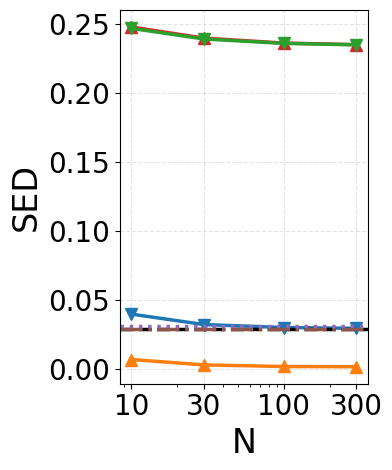

Saved metric figure to: save/doubling1d_results/doubling1d_es1_vs_N.png
Saved metric figure PDF to: save/doubling1d_results/doubling1d_es1_vs_N.pdf


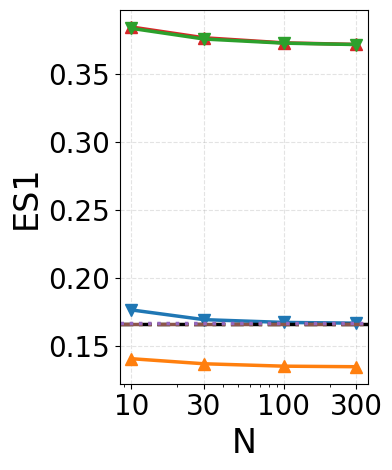

Saved metric figure to: save/doubling1d_results/doubling1d_rank_hist_rhvar_vs_N.png
Saved metric figure PDF to: save/doubling1d_results/doubling1d_rank_hist_rhvar_vs_N.pdf


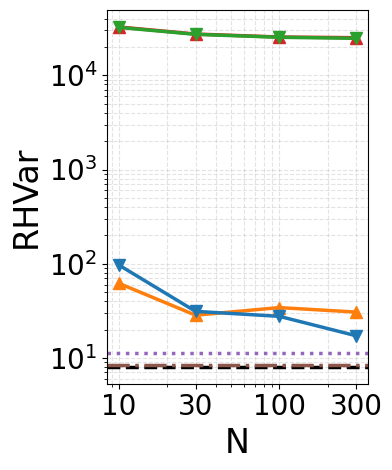

Saved horizontal legend figure to: save/doubling1d_results/doubling1d_metrics_vs_N_legend_horizontal.png
Saved horizontal legend figure PDF to: save/doubling1d_results/doubling1d_metrics_vs_N_legend_horizontal.pdf


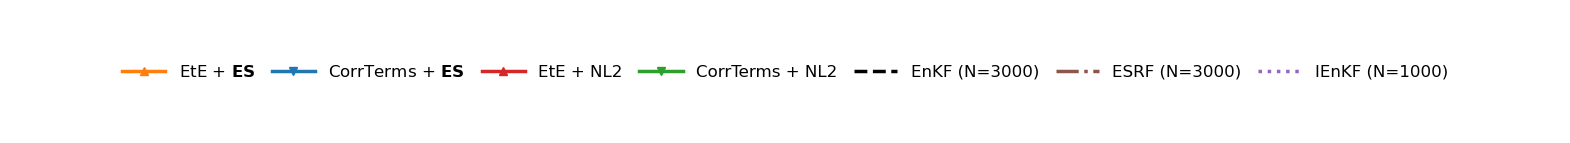

Saved vertical legend figure to: save/doubling1d_results/doubling1d_metrics_vs_N_legend_vertical.png
Saved vertical legend figure PDF to: save/doubling1d_results/doubling1d_metrics_vs_N_legend_vertical.pdf


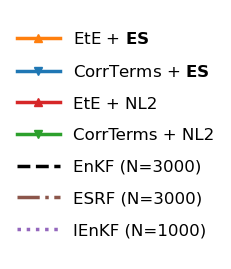

In [4]:
from pathlib import Path
import math
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import torch

base_dir = Path('save/doubling1d_results')
benchmark_dirs = {
    'EnKF': Path('save/benchmark_doubling1d_0.2_EnKF'),
    'ESRF': Path('save/benchmark_doubling1d_0.2_ESRF'),
    'IEnKF': Path('save/benchmark_doubling1d_0.2_iEnKS-PertObs'),
}

methods = [
    ('EtE + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_EtE-LResNone_cos2pi'),
    ('CorrTerms + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_CorrTermsNone_cos2pi'),
    ('EtE + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_EtE-LResNone_cos2pi'),
    ('CorrTerms + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_CorrTermsNone_cos2pi'),
]

metric_specs = [
    ('SED', ('mean_pf_sed', 'pf_sed'), 'pf_sed'),
    ('ES1', ('mean_es1', 'es1'), 'es1'),
    ('RHVar', ('rank_freq_var',), 'rank_hist_rhvar'),
]

selected_ns = [10, 30, 100, 300]
axis_label_fontsize = 24
tick_fontsize = 20

# Metric figures are saved and displayed with the same layout (no legend).
fig_width_no_legend = 4
fig_height = 4.8
METRIC_LEGEND_WIDTH = 1.9
METRIC_LEGEND_HEIGHT_PER_ITEM = 0.42
METRIC_LEGEND_BASE_HEIGHT = 0.3

series_styles = {
    'CorrTerms + ES': {'color': '#1f77b4', 'marker': 'v', 'linestyle': '-', 'x_factor': 1.0},
    'EtE + ES': {'color': '#ff7f0e', 'marker': '^', 'linestyle': '-', 'x_factor': 1.0},
    'CorrTerms + NL2': {'color': '#2ca02c', 'marker': 'v', 'linestyle': '-', 'x_factor': 1.0},
    'EtE + NL2': {'color': '#d62728', 'marker': '^', 'linestyle': '-', 'x_factor': 1.0},
}
benchmark_styles = {
    'EnKF': {'color': 'black', 'linestyle': '--'},
    'ESRF': {'color': '#8c564b', 'linestyle': '-.'},
    'IEnKF': {'color': '#9467bd', 'linestyle': ':'},
}


def format_es_legend_label(label):
    if label.startswith('ESRF'):
        return label
    if label == 'ES1':
        return r'$\mathbf{ES}$'
    return label.replace('ES', r'$\mathbf{ES}$')


def extract_metric(payload, candidate_keys):
    metric_sources = [payload.get('nn', {}), payload.get('test_results', {})]
    for key in candidate_keys:
        for source in metric_sources:
            if key in source:
                return float(source[key])
    return float('nan')


RANK_HIST_RAW_VAR_KEYS = ('rank_freq_var',)
RANK_HIST_SAMPLE_KEYS = ('rank_total_samples',)


def normalized_rhvar_from_record(payload, ensemble_size):
    raw = extract_metric(payload, RANK_HIST_RAW_VAR_KEYS)
    sample_count = extract_metric(payload, RANK_HIST_SAMPLE_KEYS)
    if (
        not math.isfinite(raw)
        or not math.isfinite(sample_count)
        or sample_count <= 0
        or ensemble_size <= 0
    ):
        return float('nan')
    return raw * sample_count * (ensemble_size + 1.0) ** 2 / ensemble_size


def is_rhvar_metric(metric_label):
    return str(metric_label).upper() == 'RHVAR'


def collect_metric_series(folder):
    records = []
    for path in sorted(folder.glob('output_records_*.pt')):
        n_str = path.stem.replace('output_records_', '')
        try:
            ensemble_size = int(n_str)
        except ValueError:
            continue

        payload = torch.load(path, map_location='cpu')
        row = {'N': ensemble_size}
        for metric_label, candidate_keys, _ in metric_specs:
            if any(key in RANK_HIST_RAW_VAR_KEYS for key in candidate_keys):
                row[metric_label] = normalized_rhvar_from_record(payload, ensemble_size)
            else:
                row[metric_label] = extract_metric(payload, candidate_keys)
        records.append(row)

    if not records:
        raise FileNotFoundError(f'No output_records_*.pt files found in {folder}')

    records.sort(key=lambda row: row['N'])
    return records


def draw_metric(ax, metric_label):
    for series_label, _ in methods:
        rows = series_map[series_label]
        style = series_styles[series_label]
        valid_points = [
            (row['N'] * style['x_factor'], row[metric_label])
            for row in rows
            if row['N'] in selected_ns and math.isfinite(row[metric_label])
        ]
        if not valid_points:
            continue

        xs, ys = zip(*valid_points)
        ax.plot(
            xs,
            ys,
            marker=style['marker'],
            linestyle=style['linestyle'],
            linewidth=2.5,
            markersize=8,
            color=style['color'],
            label=series_label,
        )

    for benchmark_label, reference_row in benchmark_reference_rows.items():
        benchmark_value = reference_row[metric_label]
        if math.isfinite(benchmark_value):
            style = benchmark_styles[benchmark_label]
            ax.axhline(
                benchmark_value,
                linewidth=2.5,
                linestyle=style['linestyle'],
                color=style['color'],
                label=f"{benchmark_label} (N={reference_row['N']})",
            )

    ax.set_xlabel('N', fontsize=axis_label_fontsize)
    ax.set_ylabel(metric_label, fontsize=axis_label_fontsize)
    ax.set_xscale('log')
    ax.set_xticks(selected_ns)
    ax.get_xaxis().set_major_formatter(ScalarFormatter())
    if is_rhvar_metric(metric_label):
        ax.set_yscale('log')
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.grid(True, linestyle='--', alpha=0.35, which='both' if is_rhvar_metric(metric_label) else 'major')


series_map = {
    label: collect_metric_series(base_dir / folder_name)
    for label, folder_name in methods
}
benchmark_series_map = {
    benchmark_label: collect_metric_series(benchmark_dir)
    for benchmark_label, benchmark_dir in benchmark_dirs.items()
}
benchmark_reference_rows = {
    benchmark_label: max(rows, key=lambda row: row['N'])
    for benchmark_label, rows in benchmark_series_map.items()
}

ml_legend_labels = [label for label, _ in methods]
ml_legend_handles = [
    Line2D([0], [0], linewidth=2.5, marker=series_styles[label]['marker'], linestyle=series_styles[label]['linestyle'], color=series_styles[label]['color'])
    for label, _ in methods
]
benchmark_legend_labels = [
    f"{benchmark_label} (N={benchmark_reference_rows[benchmark_label]['N']})"
    for benchmark_label in benchmark_dirs
]
benchmark_legend_handles = [
    Line2D([0], [0], linewidth=2.5, linestyle=benchmark_styles[benchmark_label]['linestyle'], color=benchmark_styles[benchmark_label]['color'])
    for benchmark_label in benchmark_dirs
]

for metric_label, _, metric_key in metric_specs:
    fig_metric, ax_metric = plt.subplots(figsize=(fig_width_no_legend, fig_height))
    draw_metric(ax_metric, metric_label)
    fig_metric.tight_layout()
    output_path = base_dir / f'doubling1d_{metric_key}_vs_N.png'
    output_pdf_path = output_path.with_suffix('.pdf')
    fig_metric.savefig(output_path, dpi=220, bbox_inches='tight')
    fig_metric.savefig(output_pdf_path, bbox_inches='tight')
    print(f'Saved metric figure to: {output_path}')
    print(f'Saved metric figure PDF to: {output_pdf_path}')
    plt.show()
    plt.close(fig_metric)


legend_labels = [format_es_legend_label(label) for label in ml_legend_labels + benchmark_legend_labels]
legend_handles = ml_legend_handles + benchmark_legend_handles

legend_horizontal_fig, legend_horizontal_ax = plt.subplots(figsize=(20, 1.6))
legend_horizontal_ax.axis('off')
legend_horizontal_ax.legend(
    legend_handles,
    legend_labels,
    loc='center',
    ncol=len(legend_handles),
    frameon=False,
    handlelength=2.6,
    columnspacing=1.0,
    fontsize=12,
)

legend_horizontal_output_path = base_dir / 'doubling1d_metrics_vs_N_legend_horizontal.png'
legend_horizontal_output_pdf_path = legend_horizontal_output_path.with_suffix('.pdf')
legend_horizontal_fig.savefig(legend_horizontal_output_path, dpi=220, bbox_inches='tight', pad_inches=0.06)
legend_horizontal_fig.savefig(legend_horizontal_output_pdf_path, bbox_inches='tight', pad_inches=0.06)
print(f'Saved horizontal legend figure to: {legend_horizontal_output_path}')
print(f'Saved horizontal legend figure PDF to: {legend_horizontal_output_pdf_path}')
plt.show()
plt.close(legend_horizontal_fig)

legend_vertical_fig, legend_vertical_ax = plt.subplots(
    figsize=(
        METRIC_LEGEND_WIDTH,
        METRIC_LEGEND_HEIGHT_PER_ITEM * len(legend_labels) + METRIC_LEGEND_BASE_HEIGHT,
    )
)
legend_vertical_ax.axis('off')
legend_vertical_ax.legend(
    legend_handles,
    legend_labels,
    loc='center',
    ncol=1,
    frameon=False,
    handlelength=2.6,
    columnspacing=1.0,
    labelspacing=1.0,
    fontsize=12,
)

legend_vertical_output_path = base_dir / 'doubling1d_metrics_vs_N_legend_vertical.png'
legend_vertical_output_pdf_path = legend_vertical_output_path.with_suffix('.pdf')
legend_vertical_fig.savefig(legend_vertical_output_path, dpi=220, bbox_inches='tight', pad_inches=0.06)
legend_vertical_fig.savefig(legend_vertical_output_pdf_path, bbox_inches='tight', pad_inches=0.06)
print(f'Saved vertical legend figure to: {legend_vertical_output_path}')
print(f'Saved vertical legend figure PDF to: {legend_vertical_output_pdf_path}')
plt.show()
plt.close(legend_vertical_fig)





Saved SED/RHVar triptych figure to: save/doubling1d_results/doubling1d_sed_rhvar_triptych.png
Saved SED/RHVar triptych figure PDF to: save/doubling1d_results/doubling1d_sed_rhvar_triptych.pdf


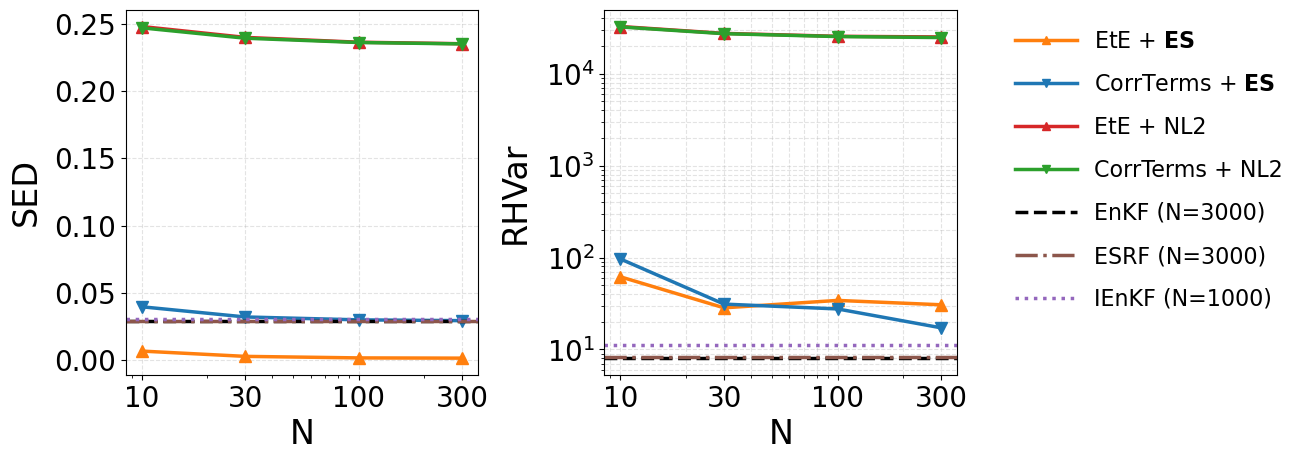

In [5]:
# SED/RHVar triptych with vertical legend
triptych_fig = plt.figure(figsize=(12.6, fig_height))

ax_sed = triptych_fig.add_axes([0.08, 0.16, 0.28, 0.76])
ax_rhvar = triptych_fig.add_axes([0.46, 0.16, 0.28, 0.76])
ax_legend = triptych_fig.add_axes([0.77, 0.16, 0.21, 0.76])

for ax, metric_label in [(ax_sed, 'SED'), (ax_rhvar, 'RHVar')]:
    draw_metric(ax, metric_label)

ax_sed.yaxis.labelpad = 8
ax_rhvar.yaxis.labelpad = 10
ax_legend.axis('off')
ax_legend.legend(
    legend_handles,
    legend_labels,
    loc='upper left',
    bbox_to_anchor=(0.0, 1.0),
    ncol=1,
    frameon=False,
    handlelength=2.8,
    handletextpad=0.75,
    labelspacing=0.9,
    fontsize=16,
)

triptych_output_path = base_dir / 'doubling1d_sed_rhvar_triptych.png'
triptych_output_pdf_path = triptych_output_path.with_suffix('.pdf')
triptych_fig.savefig(triptych_output_path, dpi=220, bbox_inches='tight', pad_inches=0.06)
triptych_fig.savefig(triptych_output_pdf_path, bbox_inches='tight', pad_inches=0.06)
print(f'Saved SED/RHVar triptych figure to: {triptych_output_path}')
print(f'Saved SED/RHVar triptych figure PDF to: {triptych_output_pdf_path}')
plt.show()
plt.close(triptych_fig)


sliced energy distance = $\int (F(x) - F^*(x))^2 dx$, $F(x)$ is the CDF